In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Analisis exploratorio y preparacion de los datos


## Carga y Limpieza de Datos

In [3]:
# 1. Cargar el dataset usando la ruta relativa
ruta = '../rideshare_kaggle.csv'
df = pd.read_csv(ruta)

### Visualizar datos faltantes

In [3]:
# 2. Validar valores nulos en el dataset original

valores_nulos = df.isna().sum()
null_values_dict = {column: count for column, count in valores_nulos.items() if count > 0}
na_values_dict = {column: count for column, count in valores_nulos.items() if count > 0}

print(null_values_dict)
print(na_values_dict)

{'price': 55095}
{'price': 55095}


In [4]:
nulos = df.isna().sum().to_frame("n_nulos")
nulos["pct"] = (nulos["n_nulos"] / len(df) * 100).round(2)
nulos[nulos["n_nulos"] > 0].sort_values("pct", ascending=False)


,n_nulos,pct
price,55095,7.95


<Axes: >

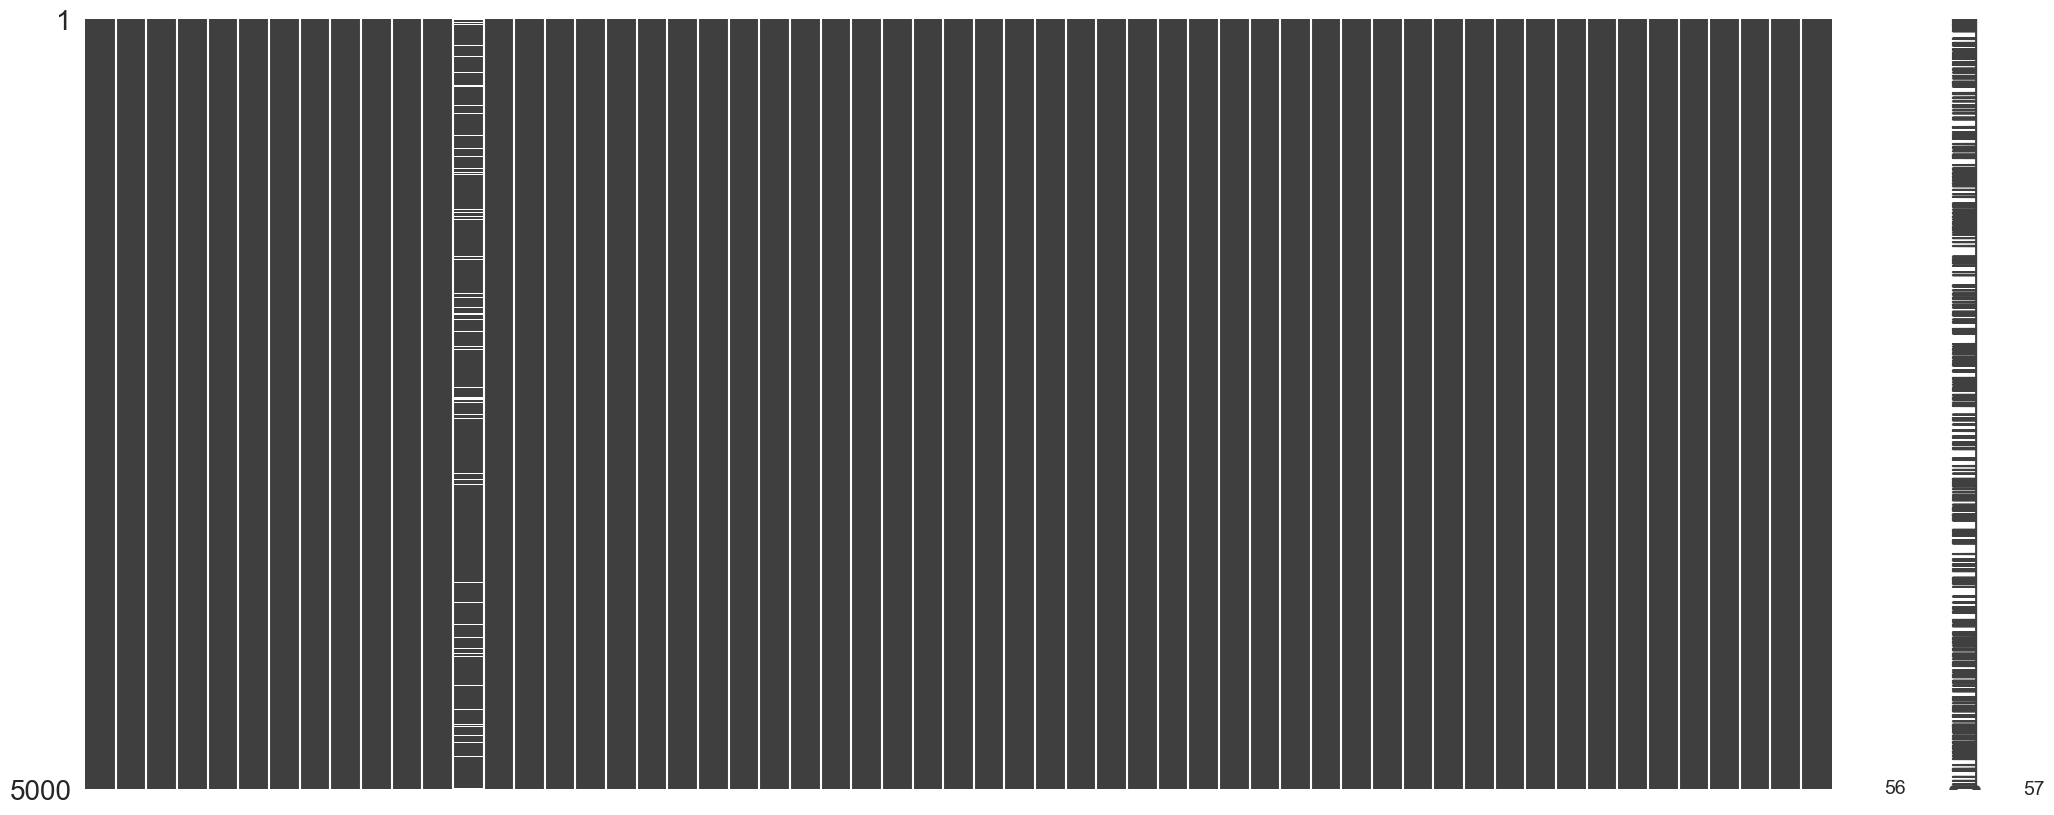

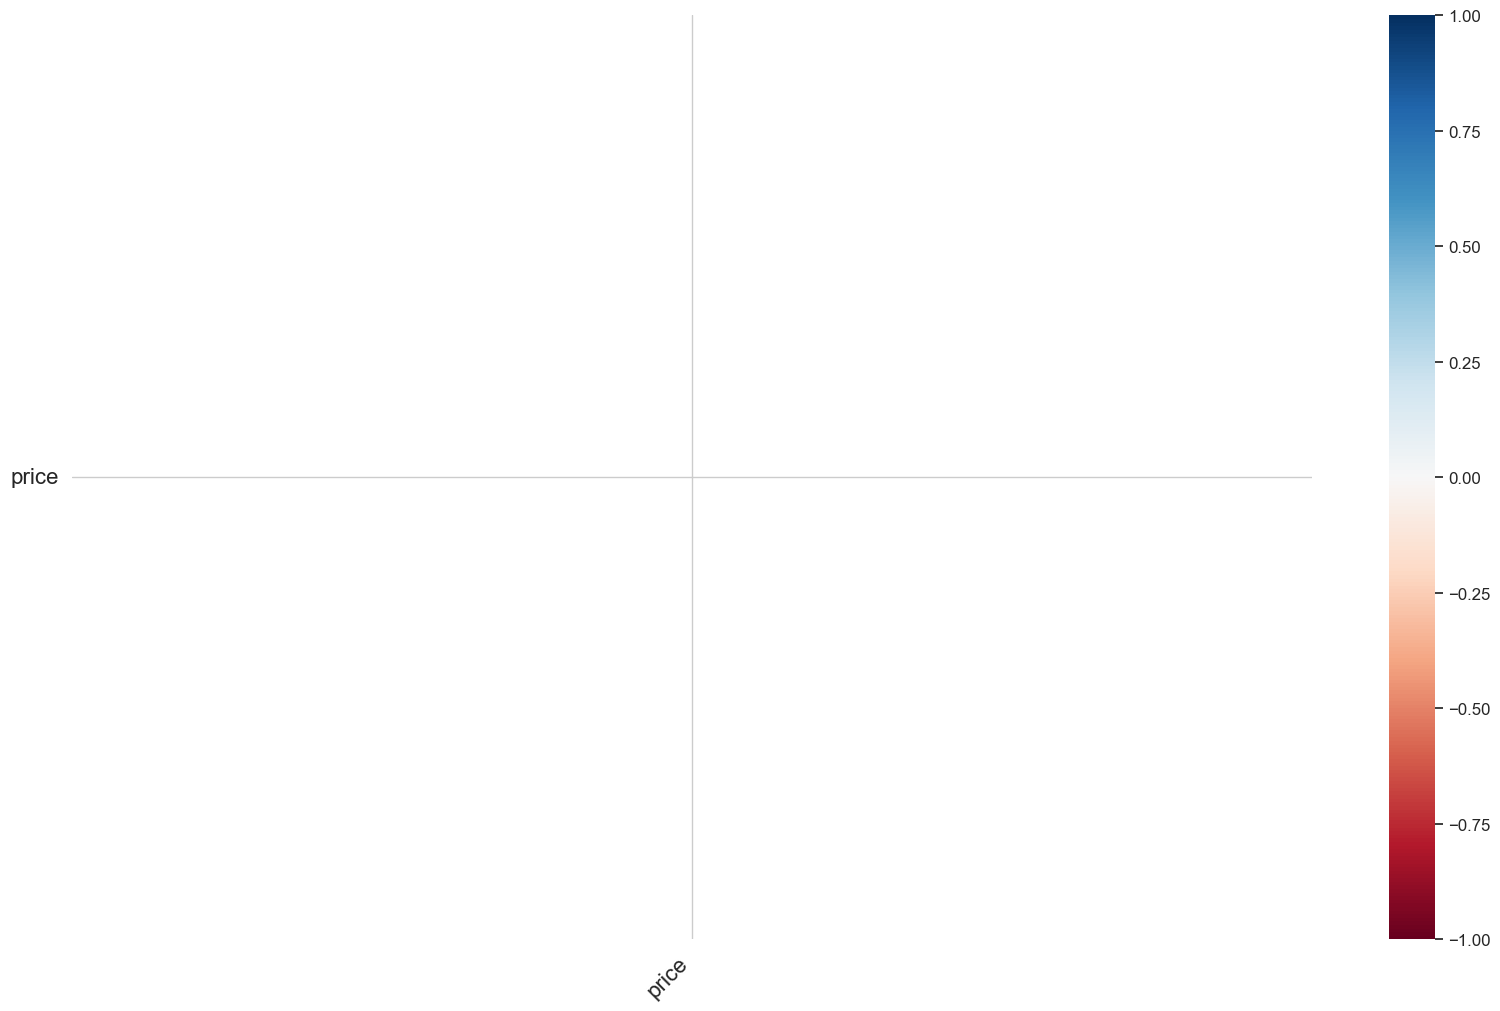

In [5]:
# Visualizar patrones de datos faltantes en el dataset original
msno.matrix(df.sample(5000, random_state=42))
msno.heatmap(df)

In [6]:
# Confirmar: ¿qué tienen en común las filas con price nulo en el dataset original?
print(df[df["price"].isna()]["name"].value_counts())
print(df[df["price"].isna()]["cab_type"].value_counts())

name
Taxi    55095
Name: count, dtype: int64
cab_type
Uber    55095
Name: count, dtype: int64


In [4]:
# 3. Filtrar los nulos de 'price' (categoría Taxi)
df_clean = df.dropna(subset=['price']).copy()

print(f"Filas originales: {len(df)}")
print(f"Filas limpias (sin Taxi): {len(df_clean)}")
print(f"Dimensiones del dataset: {df_clean.shape}")

Filas originales: 693071
Filas limpias (sin Taxi): 637976
Dimensiones del dataset: (637976, 57)


In [8]:
df_information_original = df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 637976 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           637976 non-null  object 
 1   timestamp                    637976 non-null  float64
 2   hour                         637976 non-null  int64  
 3   day                          637976 non-null  int64  
 4   month                        637976 non-null  int64  
 5   datetime                     637976 non-null  object 
 6   timezone                     637976 non-null  object 
 7   source                       637976 non-null  object 
 8   destination                  637976 non-null  object 
 9   cab_type                     637976 non-null  object 
 10  product_id                   637976 non-null  object 
 11  name                         637976 non-null  object 
 12  price                        637976 non-null  float64
 13  dist

### Estadisticas de las variables numericas

In [9]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,637976.0,1.544046e+09,689202.790112,1.543204e+09,1.543444e+09,1.543737e+09,1.544828e+09,1.545161e+09
hour,637976.0,1.161853e+01,6.948776,0.000000e+00,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day,637976.0,1.779767e+01,9.982083,1.000000e+00,1.300000e+01,1.700000e+01,2.800000e+01,3.000000e+01
month,637976.0,1.158655e+01,0.492452,1.100000e+01,1.100000e+01,1.200000e+01,1.200000e+01,1.200000e+01
price,637976.0,1.654513e+01,9.324359,2.500000e+00,9.000000e+00,1.350000e+01,2.250000e+01,9.750000e+01
distance,637976.0,2.189261e+00,1.135413,2.000000e-02,1.270000e+00,2.160000e+00,2.930000e+00,7.860000e+00
surge_multiplier,637976.0,1.015068e+00,0.095422,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
latitude,637976.0,4.233816e+01,0.047856,4.221480e+01,4.235030e+01,4.235190e+01,4.236470e+01,4.236610e+01
longitude,637976.0,-7.106614e+01,0.020303,-7.110540e+01,-7.108100e+01,-7.106310e+01,-7.105420e+01,-7.103300e+01
temperature,637976.0,3.958241e+01,6.725500,1.891000e+01,3.645000e+01,4.049000e+01,4.358000e+01,5.722000e+01


## Interpretación de Estadísticas Descriptivas

### Variables clave del objetivo y predictoras principales

| Variable | Media | Mediana | Std | Min | Max | Comentario |
|---|---:|---:|---:|---:|---:|---|
| **price** | 16.55 | 13.50 | 9.32 | 2.50 | 97.50 | Sesgo derecho; objetivo principal |
| **distance** | 2.19 | 2.16 | 1.14 | 0.02 | 7.86 | Miles; predictor #1 (corr ~0.35) |
| **surge_multiplier** | 1.02 | 1.00 | 0.10 | 1.00 | 3.00 | Mayormente 1.0; picos de demanda |
| **hour** | 11.6 | 12 | 6.95 | 0 | 23 | Distribución amplia; captura hora punta |
| **temperature** | 39.6°F | 40.5°F | 6.7 | 18.9 | 57.2 | Rango invernal (Boston, nov-dic) |
| **humidity** | 0.74 | 0.71 | 0.14 | 0.38 | 0.96 | Alta humedad relativa |
| **latitude/longitude** | 42.34 / -71.07 | - | 0.05 / 0.02 | - | - | Zona Boston; baja varianza |

### Observaciones
- **`surge_multiplier`**: 90%+ de viajes tienen valor 1.0 (sin surge); solo cola larga >1.5.
- **Coordenadas**: varianza muy baja → el modelo no aprende diferencias geográficas finas, solo distancia.
- **Clima**: rangos acotados (invierno Boston); efecto marginal comparado con `distance`/`name`/`surge`.
- **Mes/Día**: dataset cubre solo **nov-dic 2018** (mes 11–12); no hay estacionalidad anual completa.


### Calidad de los datos

Verificamos:
- Filas duplicadas exactas
- Precios imposibles (≤ 0)
- Rango de horas válido (0-23)
- Cardinalidad de variables categóricas

In [10]:
df_clean.duplicated().sum()

(df_clean["price"] <= 0).sum()
df_clean["hour"].between(0, 23).all()
df_clean.nunique().sort_values()

timezone                            1
month                               2
cab_type                            2
uvIndex                             3
icon                                7
surge_multiplier                    7
short_summary                       9
latitude                           11
long_summary                       11
longitude                          12
product_id                         12
name                               12
source                             12
destination                        12
day                                17
moonPhase                          18
uvIndexTime                        20
temperatureHighTime                23
temperatureMaxTime                 23
hour                               24
temperatureMinTime                 25
windGustTime                       25
apparentTemperatureHighTime        27
apparentTemperatureMaxTime         27
precipProbability                  29
apparentTemperatureMinTime         29
temperatureL

### Variables derivadas para análisis exploratorio

Creamos `dia_semana` y `es_fin_semana` a partir de `datetime` para explorar patrones temporales. **Nota:** Estas variables no se usan en el modelo final (el pipeline usa `hour`, `day`, `month` directamente), pero son útiles para el EDA.

In [11]:
# Variables derivadas para análisis exploratorio (no se usan en el modelo final)
df_clean["datetime"] = pd.to_datetime(df_clean["datetime"])
df_clean["dia_semana"] = df_clean["datetime"].dt.dayofweek
df_clean["es_fin_semana"] = (df_clean["dia_semana"] >= 5).astype(int)
print("Variables derivadas creadas: dia_semana, es_fin_semana")

Variables derivadas creadas: dia_semana, es_fin_semana


### Analisis exploratorio

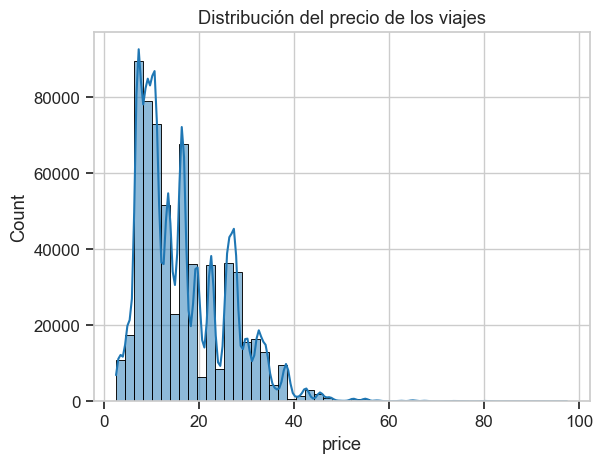

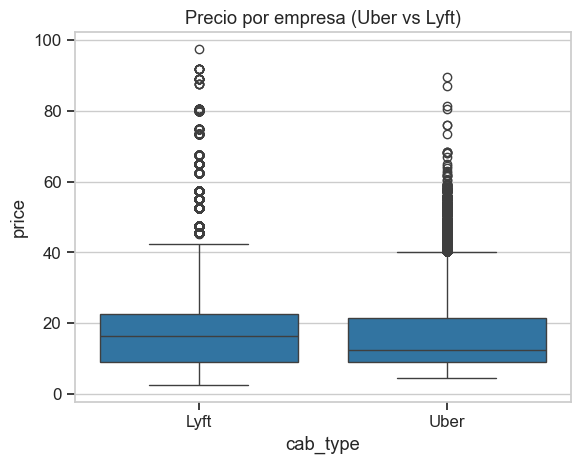

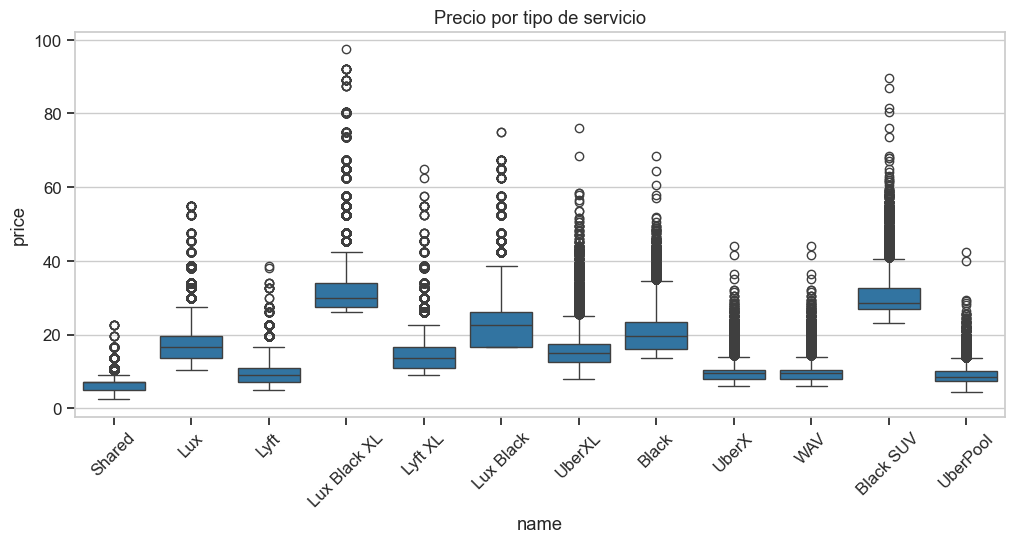

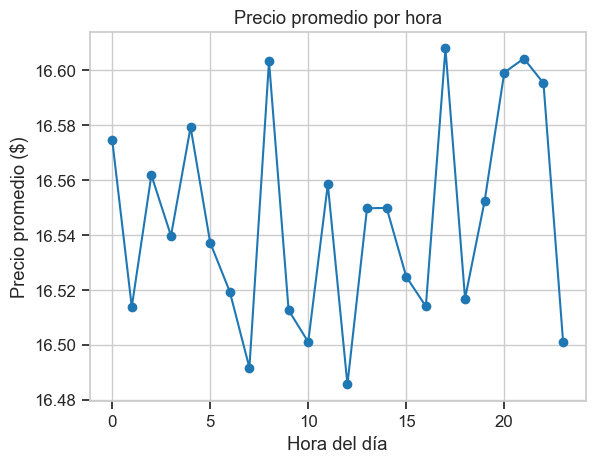

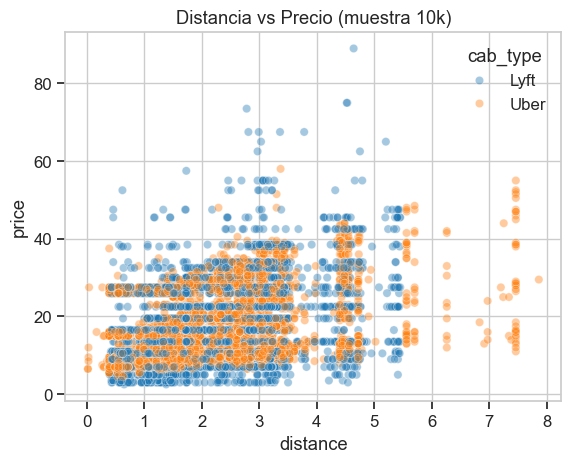

In [12]:
# Distribución del objetivo (price): ¿sesgo? ¿outliers?
sns.histplot(df_clean["price"].dropna(), bins=50, kde=True)
plt.title('Distribución del precio de los viajes')
plt.show()

# Precio por empresa y por tipo de servicio
sns.boxplot(data=df_clean, x="cab_type", y="price")
plt.title('Precio por empresa (Uber vs Lyft)')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x="name", y="price")
plt.xticks(rotation=45)
plt.title('Precio por tipo de servicio')
plt.show()

# Precio promedio por hora del día
df_clean.groupby("hour")["price"].mean().plot(marker="o")
plt.ylabel("Precio promedio ($)")
plt.xlabel("Hora del día")
plt.title('Precio promedio por hora')
plt.show()

# Distancia vs precio (muestra para no saturar el gráfico)
sns.scatterplot(data=df_clean.sample(10000, random_state=42),
                x="distance", y="price", hue="cab_type", alpha=0.4)
plt.title('Distancia vs Precio (muestra 10k)')
plt.show()

## Interpretación del Análisis Exploratorio

### 1. Distribución del precio (`price`)
- **Sesgo positivo marcado**: la mayoría de viajes cuestan entre **$5–$25**, con una cola larga hacia valores altos (hasta ~$100).
- **Media ($16.5) > Mediana ($13.5)**: confirma asimetría derecha; pocos viajes muy caros tiran de la media.
- **Mínimo $2.50**: compatible con tarifas base mínimas.
- **Implicación para modelado**: el objetivo no es gaussiano; métricas como MAE/RMSE son más interpretables que R² solo. Considerar transformaciones (log) si los residuos no son normales.

### 2. Precio por empresa (`cab_type`: Uber vs Lyft)
- **Distribuciones muy similares**: medianas e IQRs casi idénticos.
- **Outliers**: ambas tienen viajes caros (> $60), pero Lyft muestra ligeramente más dispersión en el extremo superior.
- **Conclusión**: `cab_type` sola no es un predictor fuerte de precio; la diferenciación real está en el **tipo de servicio** (`name`).

### 3. Precio por tipo de servicio (`name`)
- **Jerarquía clara de precios**:
  - **Bajo**: `UberPool` / `Shared` (compartidos) ~ $8–12 mediana
  - **Medio**: `UberX` / `Lyft` (estándar) ~ $12–16 mediana
  - **Alto**: `UberXL` / `Lyft XL` (grupos) ~ $18–25 mediana
  - **Premium**: `Black` / `Black SUV` / `Lux` / `Lux Black` / `WAV` ~ $25–50+ mediana
- **`name` es la variable categórica más informativa** para el precio; captura el segmento de producto.

### 4. Precio promedio por hora del día
- **Patrón bimodal**: picos en **horas punta** (7–9 AM y 17–19 PM) donde la demanda sube.
- **Valle nocturno** (0–5 AM): precios más bajos, menos tráfico, menor `surge_multiplier`.
- **Mediodía (11–15)**: precios intermedios y estables.
- **`hour` captura efecto de demanda/hora punta**; interactúa con `surge_multiplier`.

### 5. Distancia vs Precio
- **Relación lineal positiva fuerte**: a mayor distancia, mayor precio (esperable).
- **Dispersión vertical**: para una misma distancia, precios varían por `name`, `surge_multiplier`, hora.
- **Dos nubes por `cab_type`**: Uber y Lyft tienen estructuras de tarifa similares por distancia.
- **`distance` es el predictor numérico #1** (correlación ~0.35).


### Correlaciones y redundancias

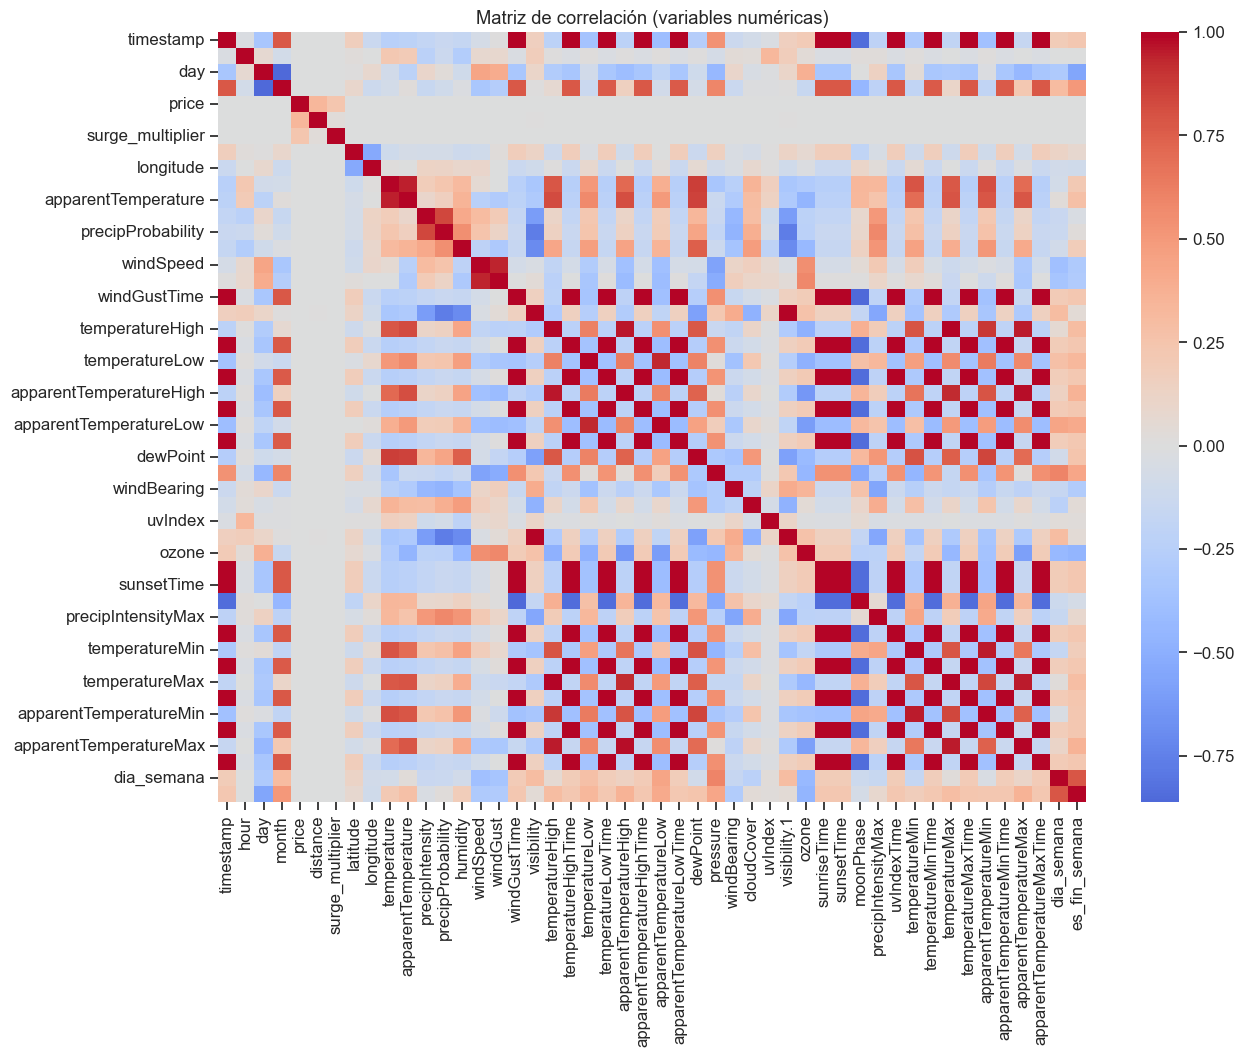

Pares con correlación > 0.9:
visibility               visibility.1                   1.000000
sunriseTime              sunsetTime                     1.000000
sunsetTime               uvIndexTime                    0.999997
sunriseTime              uvIndexTime                    0.999997
temperatureHighTime      apparentTemperatureHighTime    0.999986
                                                          ...   
temperatureHigh          apparentTemperatureMax         0.951037
temperature              apparentTemperature            0.946157
windSpeed                windGust                       0.937649
temperatureLow           apparentTemperatureLow         0.933931
apparentTemperatureHigh  temperatureMax                 0.926408
Length: 89, dtype: float64


In [13]:
num = df_clean.select_dtypes(include="number")
corr = num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

# Pares de variables casi idénticas (candidatas a eliminar)
corr_abs = corr.abs()
mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)  # solo triángulo superior
pares = corr_abs.where(mask).stack().sort_values(ascending=False)
print("Pares con correlación > 0.9:")
print(pares[pares > 0.9])

## Interpretación de la Matriz de Correlación

### Correlaciones con el objetivo (`price`)

| Variable | Correlación | Interpretación |
|---|---:|---|
| **distance** | **+0.35** | Predictor numérico más fuerte; relación lineal clara |
| **surge_multiplier** | **+0.24** | Captura picos de demanda; efecto multiplicativo |
| **latitude** | +0.002 | Prácticamente nula; coordenadas no predicen precio directamente |
| **month/moonPhase** | ~0.001 | Ruido; mes solo 11-12, fase lunar irrelevante |

### Redundancias detectadas (|r| > 0.9) — eliminadas en auditoría

- `visibility` ↔ `visibility.1` (**1.00**) → duplicada exacta
- `temperature` ↔ `apparentTemperature` (**0.95**) → sensación térmica ≈ real
- `windSpeed` ↔ `windGust` (**0.94**) → correlación física esperada
- Variables `*High`/`*Low`/`*Max`/`*Min` ↔ sus homólogas `apparent*` (**0.92–0.95**)
- `sunriseTime` ↔ `sunsetTime` ↔ `uvIndexTime` (**~1.00**) → mismos timestamps diarios

### Conclusiones para modelado
1. **Solo `distance` y `surge_multiplier`** tienen señal lineal clara con `price`.
2. **Variables meteorológicas** aportan señal marginal; su valor está en interacciones no lineales (ej. lluvia + hora punta → más surge).
3. **Redundancias confirmadas**: la auditoría de fuga elimina correctamente las variables duplicadas/futuras.
4. **Baja correlación ≠ inutilidad**: `hour`, `name`, `cab_type` tienen relación **no lineal** con precio (capturada por árboles/boosting).


## Prevención de fuga de información

La fuga de información ocurre cuando el modelo se entrena con datos que no estarían
disponibles en el momento real de la predicción, o cuando el conjunto de prueba
influye en el proceso de entrenamiento. Produce métricas optimistas que no se
sostienen frente a datos nuevos.

En este proyecto la predicción se realiza en el instante en que un usuario solicita
una cotización de viaje. Toda variable que no se conozca en ese instante queda fuera
del modelo.

Aplicamos cuatro controles, desarrollados en las celdas siguientes:

1. Auditoría de variables, para descartar identificadores, columnas redundantes y
   variables cuyo valor solo se conoce después del viaje.
2. Encapsulamiento de todas las transformaciones en un `Pipeline`, ajustado
   exclusivamente con los datos de entrenamiento.
3. Verificación de que ninguna variable predictora reproduzca la variable objetivo.
4. Justificación del método de separación entre entrenamiento y prueba.

In [7]:
import pandas as pd

# ---------------------------------------------------------------
# Control 1: auditoría de variables predictoras
# ---------------------------------------------------------------

# 1.a Identificadores y marcas de tiempo.
# No describen el viaje, solo lo etiquetan. Un identificador puede permitir que el
# modelo memorice observaciones individuales en lugar de aprender el patrón.
cols_identificadores = ['id', 'timestamp', 'datetime', 'product_id']

# 1.b Variables conocidas solo después del evento.
# El dataset incluye agregados meteorológicos del DÍA COMPLETO (máximos, mínimos,
# valores altos y bajos) y marcas de tiempo futuras (hora del amanecer, del atardecer,
# del pico de índice UV). En el momento de cotizar un viaje a las 10:00 a.m. todavía
# no se conoce la temperatura máxima de ese día. Usarlas sería fuga de información
# según el punto 6.6: "no se utilicen variables que solo se conocen después del
# evento que se desea predecir".
patrones_futuro = ('Max', 'Min', 'High', 'Low')
cols_futuro = [
    c for c in df_clean.columns
    if c.endswith('Time') or any(p in c for p in patrones_futuro)
]

# 1.c Columnas duplicadas o redundantes.
# 'visibility.1' es una copia de 'visibility'. 'product_id' codifica exactamente la
# misma información que 'name', por eso ya está en la lista de identificadores.
cols_redundantes = [c for c in df_clean.columns if c.endswith('.1')]

# 1.d Resúmenes de texto del día completo.
# 'long_summary' describe el pronóstico de TODO el día (por ejemplo "Rain throughout
# the day"), por lo que tiene el mismo problema que los máximos y mínimos diarios.
# 'short_summary' e 'icon' describen la condición de la hora actual y sí se conocen al
# cotizar; no se excluyen por fuga, aunque el modelo no las usa (ver el Pipeline).
cols_resumen_diario = ['long_summary']

cols_excluidas = sorted(set(cols_identificadores + cols_futuro + cols_redundantes
                            + cols_resumen_diario)
                        & set(df_clean.columns))

print(f"Variables excluidas por auditoría: {len(cols_excluidas)}")
for c in cols_excluidas:
    print(f"  - {c}")

df_auditado = df_clean.drop(columns=cols_excluidas)
print(f"\nVariables conservadas: {df_auditado.shape[1] - 1} predictoras + 1 objetivo")

Variables excluidas por auditoría: 27
  - apparentTemperatureHigh
  - apparentTemperatureHighTime
  - apparentTemperatureLow
  - apparentTemperatureLowTime
  - apparentTemperatureMax
  - apparentTemperatureMaxTime
  - apparentTemperatureMin
  - apparentTemperatureMinTime
  - datetime
  - id
  - long_summary
  - precipIntensityMax
  - product_id
  - sunriseTime
  - sunsetTime
  - temperatureHigh
  - temperatureHighTime
  - temperatureLow
  - temperatureLowTime
  - temperatureMax
  - temperatureMaxTime
  - temperatureMin
  - temperatureMinTime
  - timestamp
  - uvIndexTime
  - visibility.1
  - windGustTime

Variables conservadas: 29 predictoras + 1 objetivo


In [8]:
# ---------------------------------------------------------------
# Control 3: ninguna variable predictora reproduce la variable objetivo
# ---------------------------------------------------------------

num = df_auditado.select_dtypes(include='number')
corr_precio = num.corr()['price'].drop('price').abs().sort_values(ascending=False)

print("Correlación absoluta con 'price' (5 más altas):")
print(corr_precio.head(5).round(4))

sospechosas = corr_precio[corr_precio > 0.95]
if len(sospechosas) == 0:
    print("\nNinguna variable numérica supera |r| = 0.95. No se detecta duplicación del objetivo.")
else:
    print(f"\nRevisar: {list(sospechosas.index)}")

Correlación absoluta con 'price' (5 más altas):
distance            0.3451
surge_multiplier    0.2405
latitude            0.0021
moonPhase           0.0016
visibility          0.0015
Name: price, dtype: float64

Ninguna variable numérica supera |r| = 0.95. No se detecta duplicación del objetivo.


**Resultado del control 3.** Ninguna variable numérica supera |r| = 0.95 con `price`.
Las más relacionadas son `distance` (0.35) y `surge_multiplier` (0.24), ambas conocidas
en el momento de cotizar; el resto está por debajo de 0.01. No hay entre las predictoras
una copia disfrazada del precio.

Este control es diagnóstico: se calcula antes de la división, pero no se usó para
eliminar ni seleccionar variables, por lo que el conjunto de prueba no influye en el
modelo.

### Separación de entrenamiento y prueba

Se utilizó `train_test_split` con 80% para entrenamiento y 20% para prueba,
`random_state=42`, sobre **582.066 observaciones** (637.976 registros con precio,
menos 55.910 filas exactamente duplicadas eliminadas en la auditoría de calidad).

El conjunto de datos es de corte transversal: cada fila corresponde
a una cotización independiente. Por esta razón la separación aleatoria es apropiada
y no se requiere un corte temporal estricto.

El dataset contiene 72 rutas únicas (origen-destino) y 13 tipos de servicio
que se repiten. Observaciones similares pueden quedar repartidas entre ambos conjuntos.
Esto es aceptable porque el objetivo es cotizar viajes sobre estas mismas rutas/servicios.

Como control adicional se eliminaron duplicados exactos antes de dividir,
para que una misma observación no aparezca en entrenamiento y prueba simultáneamente.

La sección **Robustez de la separación** verifica que ni la repetición de rutas
ni el orden temporal inflan las métricas.

In [9]:
duplicadas = df_auditado.duplicated().sum()
print(f"Filas exactamente duplicadas: {duplicadas} ({duplicadas/len(df_auditado)*100:.2f}%)")

df_final = df_auditado.drop_duplicates().reset_index(drop=True)
print(f"Filas tras eliminar duplicados: {len(df_final)}")

Filas exactamente duplicadas: 55910 (8.76%)
Filas tras eliminar duplicados: 582066


# División de Datos

In [5]:
from sklearn.model_selection import train_test_split

# Separar características (X) y variable objetivo (y)
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Train/Test Split (80/20) - aleatorio, reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Para modelos baseline rápidos usamos solo numéricas
numeric_cols = X_train.select_dtypes(include=['number']).columns
X_train_num = X_train[numeric_cols].fillna(0)
X_test_num = X_test[numeric_cols].fillna(0)

print(f"Conjunto de Entrenamiento (X_train): {X_train.shape}")
print(f"Conjunto de Prueba (X_test):         {X_test.shape}")
print(f"  - Variables numéricas: {len(numeric_cols)}")
print(f"  - Variables categóricas: {X_train.select_dtypes(exclude=['number']).shape[1]}")

Conjunto de Entrenamiento (X_train): (510380, 56)
Conjunto de Prueba (X_test):         (127596, 56)
  - Variables numéricas: 45
  - Variables categóricas: 11


# Modelos Exploratorios (solo variables numéricas)

Antes de construir el pipeline completo, probamos modelos rápidos usando solo variables numéricas
para tener una referencia (baseline) y explorar candidatos.

## Modelo 1 - Baseline (Regresión Lineal solo variables numéricas)

Modelo de referencia rápido usando solo variables numéricas para establecer una base de comparación.

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entrenar el modelo lineal simple
baseline_model = LinearRegression()
baseline_model.fit(X_train_num, y_train)

# Predicción y métricas
y_pred_base = baseline_model.predict(X_test_num)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base = mean_absolute_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print("--- MÉTRICAS MODELO BASELINE (Linear Regression) ---")
print(f"RMSE: ${rmse_base:.2f}")
print(f"MAE:  ${mae_base:.2f}")
print(f"R²:   {r2_base:.4f}")

--- MÉTRICAS MODELO BASELINE (Linear Regression) ---
RMSE: $8.48
MAE:  $6.95
R²:   0.1749


## Modelo 2 - Candidato (Random Forest limitado)

Probamos RandomForest con profundidad limitada para evitar problemas de memoria. 
Resultado: más lento y sin mejora sobre baseline → se descarta.

Nota de experimentación: Se entrenó un RandomForestRegressor con las variables numéricas. Debido a la alta carga computacional (7.5 min) y a un $R^2$ de 0.1506, se optó por utilizar HistGradientBoostingRegressor como modelo candidato principal por su eficiencia y compatibilidad con datos masivos.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Limitamos max_depth=15 para evitar que consuma toda la RAM de la Mac y sea ultrarrápido
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)

print("Entrenando Random Forest...")
rf.fit(X_train_num, y_train)

y_pred_rf = rf.predict(X_test_num)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- MÉTRICAS MODELO CANDIDATO (Random Forest) ---")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"MAE:  ${mae_rf:.2f}")
print(f"R²:   {r2_rf:.4f}")

Entrenando Random Forest...


In [6]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelo optimizado para grandes volúmenes de datos (muy rápido en Mac)
hgb_model = HistGradientBoostingRegressor(random_state=42, max_iter=100)

print("Entrenando HistGradientBoostingRegressor...")
hgb_model.fit(X_train_num, y_train)

# Predicciones
y_pred_hgb = hgb_model.predict(X_test_num)

# Métricas
rmse_hgb = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print("\n--- MÉTRICAS MODELO CANDIDATO (HistGradientBoosting) ---")
print(f"RMSE: ${rmse_hgb:.2f}")
print(f"MAE:  ${mae_hgb:.2f}")
print(f"R²:   {r2_hgb:.4f}")

Entrenando HistGradientBoostingRegressor...

--- MÉTRICAS MODELO CANDIDATO (HistGradientBoosting) ---
RMSE: $8.45
MAE:  $6.94
R²:   0.1817


---

# Pipeline Final (todas las variables: numéricas + categóricas)

Ahora construimos el modelo de producción usando **todas las variables disponibles**
después de la auditoría de fuga, con preprocesamiento encapsulado en Pipeline.

## Pipeline Final: Preprocesamiento + HistGradientBoosting

Construimos el pipeline completo que se usará en producción:
- **Variables numéricas**: imputación con mediana (calculada solo en train)
- **Variables categóricas** (`name`, `cab_type`): OneHotEncoder con `handle_unknown='ignore'`
- **Resto de columnas**: se descartan (`remainder='drop'`) — incluyen las excluidas por fuga
  y otras no usadas por decisión de modelado (`source`, `destination`, `short_summary`, `icon`, `timezone`).

Todas las transformaciones se encapsulan en un `Pipeline` para evitar fuga de información:
el preprocesador se ajusta **exclusivamente con `X_train`**.

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------------
# Control 2: todas las transformaciones dentro de un Pipeline
# ---------------------------------------------------------------

X = df_final.drop(columns=['price'])
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cols_num = X_train.select_dtypes(include='number').columns.tolist()
cols_cat = ['name', 'cab_type']

preprocesador = ColumnTransformer(
    transformers=[
        # La mediana se calcula solo con X_train. Se usa mediana y no cero porque
        # un cero en temperatura, presión o latitud es un valor físicamente posible
        # pero falso, que distorsionaría el aprendizaje.
        ('num', SimpleImputer(strategy='median'), cols_num),

        # handle_unknown='ignore': si en producción aparece un tipo de servicio que
        # no estaba en entrenamiento, el pipeline lo codifica en ceros en vez de
        # fallar. Esto era lo que el align() resolvía a mano y de forma frágil.
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cols_cat),
    ],
    # cualquier columna no listada queda fuera de forma explícita. Además de las ya
    # excluidas por fuga, quedan fuera 'source', 'destination', 'short_summary', 'icon'
    # y 'timezone': se conocen al cotizar, pero no se usan por decisión de modelado.
    remainder='drop',
)

print(f"Entrenamiento: {X_train.shape}  |  Prueba: {X_test.shape}")
print(f"Numéricas usadas: {len(cols_num)}  |  Categóricas usadas: {cols_cat}")

Entrenamiento: (465652, 29)  |  Prueba: (116414, 29)
Numéricas usadas: 22  |  Categóricas usadas: ['name', 'cab_type']


### Selección del modelo sin usar el conjunto de prueba

Comparación mediante **validación cruzada de 5 pliegues sobre `X_train` únicamente**.
El conjunto de prueba se usa **una sola vez**, al final, para evaluar el modelo ya elegido.

Candidatos evaluados (todos con el mismo preprocesamiento dentro del Pipeline):
- Dummy (mediana): baseline ingenuo
- Regresión lineal: modelo lineal
- HistGradientBoosting: modelo basado en árboles optimizado para datos masivos

Random Forest no se incluye por su costo computacional (ver nota en sección anterior).

In [11]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.base import clone

# ---------------------------------------------------------------
# Control 2b: la elección del modelo no usa el conjunto de prueba
# ---------------------------------------------------------------

# Todos los candidatos comparten el mismo preprocesamiento, dentro del Pipeline, para
# que en cada pliegue el imputador y el codificador se ajusten solo con ese pliegue.
# El Random Forest no se incluye por su costo computacional (ver nota de experimentación).
candidatos = {
    'Dummy (mediana)':      DummyRegressor(strategy='median'),
    'Regresión lineal':     LinearRegression(),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
metricas_cv = ('neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2')

resultados_cv = []
for nombre, regresor in candidatos.items():
    pipe_cv = Pipeline(steps=[
        ('preprocesamiento', clone(preprocesador)),
        ('regresor', regresor),
    ])
    # Nota: en cross_validate el prefijo 'test_' se refiere al pliegue de validación
    # dentro de X_train, no al conjunto de prueba.
    r = cross_validate(pipe_cv, X_train, y_train, cv=cv, scoring=metricas_cv)
    resultados_cv.append({
        'modelo': nombre,
        'RMSE':   -r['test_neg_root_mean_squared_error'].mean(),
        'MAE':    -r['test_neg_mean_absolute_error'].mean(),
        'R²':     r['test_r2'].mean(),
        'R² (desv.)': r['test_r2'].std(),
    })

tabla_cv = pd.DataFrame(resultados_cv).set_index('modelo').round(4)
print("--- VALIDACIÓN CRUZADA (5 pliegues, solo X_train) ---")
print(tabla_cv)
print(f"\nModelo elegido: {tabla_cv['R²'].idxmax()}")

--- VALIDACIÓN CRUZADA (5 pliegues, solo X_train) ---
                        RMSE     MAE      R²  R² (desv.)
modelo                                                  
Dummy (mediana)       9.8399  7.4901 -0.0857      0.0010
Regresión lineal      2.5790  1.8214  0.9254      0.0004
HistGradientBoosting  1.8239  1.2176  0.9627      0.0002

Modelo elegido: HistGradientBoosting


**Resultado de la selección.** Con validación cruzada sobre entrenamiento,
HistGradientBoosting obtiene R² = 0.9627 y MAE = $1.22, frente a 0.9254 y $1.82 de la
regresión lineal y a un R² negativo del modelo Dummy. La variación entre pliegues es
mínima (desviación de 0.0002), así que la diferencia entre modelos es estable. La
elección se tomó sin mirar el conjunto de prueba; al evaluarlo una única vez, el
resultado (R² = 0.9628) coincide con la estimación de validación cruzada, lo que indica
que la métrica final no está inflada.

In [12]:
import numpy as np
modelo = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('regresor', HistGradientBoostingRegressor(random_state=42)),
])

# fit() ajusta imputador y codificador ÚNICAMENTE con X_train.
# X_test nunca interviene en el aprendizaje de las transformaciones.
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("--- MÉTRICAS: Pipeline sin fuga de información ---")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

--- MÉTRICAS: Pipeline sin fuga de información ---
RMSE: $1.81
MAE:  $1.22
R²:   0.9628


### Robustez de la separación

Verificamos que la separación aleatoria no infla las métricas reentrenando con dos estrategias más exigentes:
- **Por grupos (rutas)**: rutas origen-destino de test nunca vistas en train (`GroupShuffleSplit`)
- **Temporal**: 80% más antiguo para train, 20% más reciente para test

Estas pruebas son solo diagnósticas: no se usan para elegir ni ajustar el modelo.

In [13]:
from sklearn.model_selection import GroupShuffleSplit

# ---------------------------------------------------------------
# Control 4: ¿la separación aleatoria genera fuga entre grupos o en el tiempo?
# ---------------------------------------------------------------

def evaluar_separacion(idx_train, idx_test):
    m = clone(modelo).fit(X.iloc[idx_train], y.iloc[idx_train])
    p = m.predict(X.iloc[idx_test])
    return r2_score(y.iloc[idx_test], p), mean_absolute_error(y.iloc[idx_test], p)

# a) Por grupos naturales: rutas origen-destino
rutas = X['source'] + ' -> ' + X['destination']
idx_tr, idx_te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
                      .split(X, y, groups=rutas))
r2_ruta, mae_ruta = evaluar_separacion(idx_tr, idx_te)

# b) Temporal: pasado para entrenar, futuro para evaluar
orden = np.argsort((X['month'] * 10000 + X['day'] * 100 + X['hour']).to_numpy(), kind='stable')
corte = int(len(orden) * 0.8)
r2_temp, mae_temp = evaluar_separacion(orden[:corte], orden[corte:])

print(f"Rutas distintas en el dataset: {rutas.nunique()}")
print(f"{'Separación':<34}{'R²':>8}{'MAE':>9}")
print(f"{'Aleatoria 80/20 (la utilizada)':<34}{r2_score(y_test, y_pred):>8.4f}{mean_absolute_error(y_test, y_pred):>8.2f}$")
print(f"{'Por rutas (rutas no vistas)':<34}{r2_ruta:>8.4f}{mae_ruta:>8.2f}$")
print(f"{'Temporal (pasado -> futuro)':<34}{r2_temp:>8.4f}{mae_temp:>8.2f}$")

Rutas distintas en el dataset: 72
Separación                              R²      MAE
Aleatoria 80/20 (la utilizada)      0.9628    1.22$
Por rutas (rutas no vistas)         0.9523    1.36$
Temporal (pasado -> futuro)         0.9625    1.22$


**Resultado de la robustez.** Con una separación temporal el desempeño es prácticamente
igual (R² = 0.9625), por lo que no hay fuga temporal. Con rutas nunca vistas baja
ligeramente (R² = 0.9523, MAE = $1.36): el modelo aprovecha en parte haber visto cada
ruta, pero la diferencia es pequeña. Esto respalda la decisión de usar una separación
aleatoria, dado que el modelo cotiza viajes sobre las mismas 72 rutas del dataset.

# Exportar el Modelo Final

In [ ]:
import joblib, os, sklearn

# Guardar en fase-1/ (directorio actual del notebook)
output_path = 'modelo.joblib'

artefacto = {
    'pipeline': modelo,
    'columnas_entrada_raw': X_train.columns.tolist(),
    'columnas_excluidas_por_fuga': cols_excluidas,
    'version_sklearn': sklearn.__version__,
    'metricas_test': {
        'rmse': float(np.sqrt(mean_squared_error(y_test, y_pred))),
        'mae': float(mean_absolute_error(y_test, y_pred)),
        'r2': float(r2_score(y_test, y_pred)),
    },
    'fecha_entrenamiento': pd.Timestamp.now().isoformat(),
    'n_entrenamiento': len(X_train),
    'n_prueba': len(X_test),
}

joblib.dump(artefacto, output_path)
print(f"Artefacto guardado en: {output_path}")
print(f"  - Pipeline: {type(modelo).__name__}")
print(f"  - Columnas entrada: {len(X_train.columns)}")
print(f"  - Métricas test: RMSE=${artefacto['metricas_test']['rmse']:.2f}, MAE=${artefacto['metricas_test']['mae']:.2f}, R²={artefacto['metricas_test']['r2']:.4f}")

Artefacto guardado en fase-1/modelo.joblib


In [ ]:
# Validación completa: cargar modelo y verificar predicciones
import joblib
from sklearn.metrics import mean_absolute_error

cargado = joblib.load('modelo.joblib')
pipe = cargado['pipeline']
columnas_esperadas = cargado['columnas_entrada_raw']
metricas_guardadas = cargado['metricas_test']

# Verificar columnas
print(f"Columnas esperadas por el pipeline: {len(columnas_esperadas)}")
print(f"Columnas en X_test: {len(X_test.columns)}")
assert list(X_test.columns) == columnas_esperadas, "Columnas no coinciden"

# Predicciones sobre muestra de prueba
muestra = X_test.head(500)
pred = pipe.predict(muestra)
mae_muestra = mean_absolute_error(y_test.head(500), pred)

print(f"\nPredicciones generadas: {len(pred)}")
print(f"MAE sobre muestra (500): ${mae_muestra:.2f}")
print(f"MAE guardado en artefacto: ${metricas_guardadas['mae']:.2f}")

# Primeras 5 comparaciones
print(f"\nPrimeras 5 comparaciones:")
for real, p in zip(y_test.head(5), pred[:5]):
    print(f"  real ${real:6.2f}   predicho ${p:6.2f}   diff=${abs(real-p):.2f}")

# Ejemplo individual
ejemplo = X_test.iloc[[0]]
precio_predicho = pipe.predict(ejemplo)[0]
precio_real = y_test.iloc[0]
print(f"\nEjemplo individual:")
print(f"  Precio Real:     ${precio_real:.2f} USD")
print(f"  Precio Predicho: ${precio_predicho:.2f} USD")
print(f"  Diferencia:      ${abs(precio_real - precio_predicho):.2f} USD")

print(f"\n✓ Modelo validado correctamente")

Predicciones generadas: 500
MAE sobre la muestra: $1.27

Primeras 5 comparaciones:
  real $ 22.50   predicho $ 19.56
  real $ 16.50   predicho $ 17.99
  real $ 27.50   predicho $ 26.58
  real $ 52.50   predicho $ 55.65
  real $ 16.00   predicho $ 19.07
